In [1]:
from PySpectral import *

In [2]:
niveis = 100
superposicao = 3

# superposição
coeficientes = [1]*superposicao + [0]*(niveis - superposicao)

# intervalo de tempo considerado:
tempo = 100 # [0, 100]

# total de pontos calculados dentro do intervalo:
pontos = 300

# Parâmetros
k = 1
l = -1
b = 0.27
s = 0.9999 

# Calcula grandezas derivadas
m = (6*(b+2))/s
omega = ((2*k)/(b+2))**0.5

# Define funções do problema
def f(x, m=m, omega=omega, l=l):
    return (m**2)*(omega**2) - 2*l*m*(x**4)

def g(x, m=m):
    return 2*m*x

def w(x):
    return x

# Cria root_filename dinâmico com base nos parâmetros
root_filename = f"k{k}_l{l}_b{b}_s{s}"

# Instancia o problema
p = SpectralMethod(
    num_levels=niveis,
    length=5,
    f_function=f,
    g_function=g,
    weight=w,
    num_digits=15,
    root_filename=root_filename,
    label=root_filename,
    optimizer_L='y'
)

# System description
p.is_described()

Optimizing the box length. Please wait…

L OPTIMIZATION
Number of basis functions: N = 100
Limits: L ∈ [0.1, 50.0]

[OPTIMIZATION] N=100 | Range=[0.10, 50.00]
  > Grid Min: 11.11060855079180
  > Tolerance: 1.11e-11
  > Strategy: PLATEAU (Left Edge Optimization)
  > Target Start: L=2.8531
  > Final Result: L=3.398642 (E=11.11060855079184)

Result: L_opt = 3.398641971359803
Optimized length: L = 3.398642 (N=100)
--------------------------------------------------------------------------------
Number of energy levels:       100
Interval amplitude (Length):   3.398641971359803 (float: 3.398641971359803)
f function (V_spectral):       (m**2)*(omega**2) - 2*l*m*(x**4)
g function:                    2*m*x
w function (weigth):           x
Label:                         k1_l-1_b0.27_s0.9999
Number of digits to be used:   15
The energy spectrum has not been calculated yet.
--------------------------------------------------------------------------------
Important: when using the spectral method, t

In [3]:
# Solve system
p.is_solved()

Calculating eigenvalues ...
________________________________________________________________________________
Calculating energy eigenvalues...
________________________________________________________________________________
Finished eigenvalue calculation.
________________________________________________________________________________
Spectrum saved to: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_Spectrum.txt
Time elapsed for eigenvalues calculation: 0.012073 seconds.
Calculating eigenvectors ...
________________________________________________________________________________
Calculating energy eigenvectors now ...
Eigenvectors saved to: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_Eigenvectors.txt
________________________________________________________________________________
Done!
Time elapsed for eigenvectors calculation: 0.034068 seconds.
The eigenvalue/eigenvector problem has been completely solved with 15 digits used.


In [4]:
p.its_eigenvalues(slice(1, 11))

[np.float64(7.198505432730859),
 np.float64(8.154483885374798),
 np.float64(9.12617871098099),
 np.float64(10.112034099255922),
 np.float64(11.11060855079216),
 np.float64(12.120591701806845),
 np.float64(13.140807618640665),
 np.float64(14.170209800780414),
 np.float64(15.207871660871673),
 np.float64(16.252974993819894)]

In [5]:
p.calculate_eigenvectors()
lv = p.its_eigenpairs()

Eigenvectors already calculated. Returning cached results.
Eigenpairs saved in: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_Eigenpairs.txt


Calculating 300 points.
Data on expected position has been stored in file: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_Position.txt


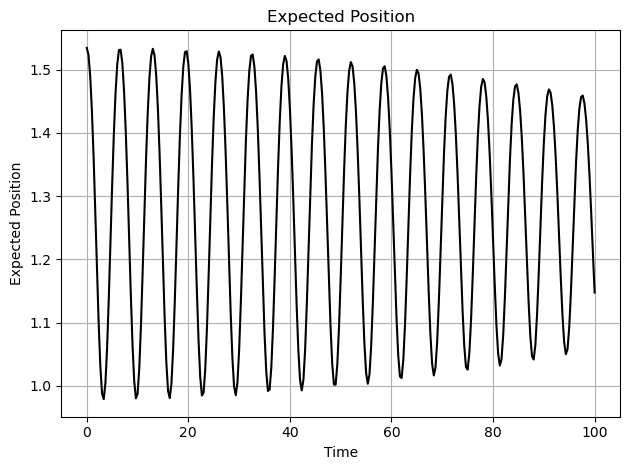

In [6]:
# Expected position
p.expected_position_is_calculated((0.0, tempo), coeficientes, num_points=pontos)

p.expected_position_is_plotted()

Expected position and uncertainty data stored in file: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_PositionUncertainty.txt


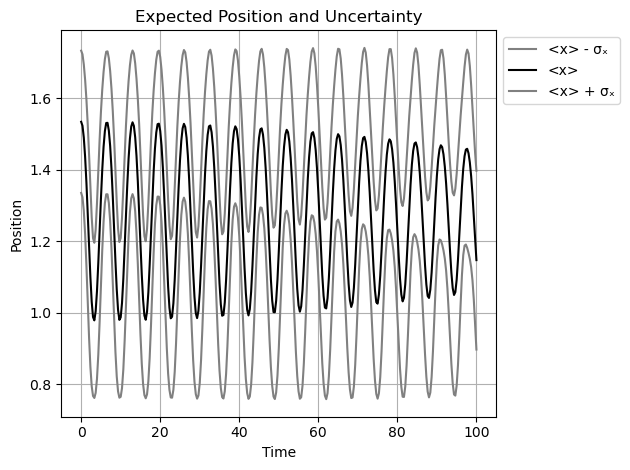

In [7]:
# Uncertainty and expected position
p.expected_position_and_uncertainty_are_calculated((0.0, tempo), coeficientes, num_points=pontos)
p.expected_position_and_uncertainty_are_plotted()

In [8]:
# NUMERIC FUNCTIONS: <x> e dx
expected_position_func = p.expected_position(coeficientes)
position_uncertainty_func = p.position_uncertainty(coeficientes)
for i in range(0, int(tempo) + 1, 5):
    print(f"t={i}: <x> = {expected_position_func(i):.15} | dx = {position_uncertainty_func(i):.15}")

t=0: <x> = 1.53427114304775 | dx = 0.19892688878921
t=5: <x> = 1.31898251731982 | dx = 0.242513992834913
t=10: <x> = 0.987093778831657 | dx = 0.222144461621753
t=15: <x> = 1.19292230926025 | dx = 0.252913509248915
t=20: <x> = 1.50879778288427 | dx = 0.206844862651368
t=25: <x> = 1.42596255024354 | dx = 0.219626282374611
t=30: <x> = 1.05667039864005 | dx = 0.253295623790041
t=35: <x> = 1.08244308051665 | dx = 0.243774827923964
t=40: <x> = 1.43778173769895 | dx = 0.223045836617691
t=45: <x> = 1.48919052509729 | dx = 0.215026093129014
t=50: <x> = 1.17137379107073 | dx = 0.271013583699827
t=55: <x> = 1.0206008602759 | dx = 0.240666565604445
t=60: <x> = 1.33705867337004 | dx = 0.234732464138296
t=65: <x> = 1.49966078584179 | dx = 0.238947823640523
t=70: <x> = 1.292693412838 | dx = 0.257816179654714
t=75: <x> = 1.02560906559778 | dx = 0.265781976794518
t=80: <x> = 1.23096771286426 | dx = 0.239283542311976
t=85: <x> = 1.46327623236811 | dx = 0.264557515738382
t=90: <x> = 1.38372918229608 | dx

Minimum value of dx(t) / <x>(t): 0.129655628140181
Estimated period(s): 
t = 0.000000000000000
Full results saved at: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_min_relative_uncertainty.txt


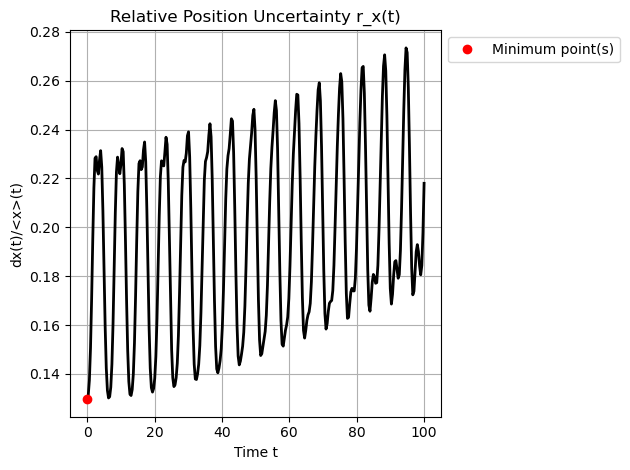

(<Figure size 640x480 with 1 Axes>,
 np.float64(0.12965562814018108),
 [np.float64(0.0)])

In [9]:
# Relative uncertainties
p.position_uncertainty_relative(coeficientes, t_max=tempo, num_points=pontos)

Expected momentum and uncertainty data stored in file: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_MomentumUncertainty.txt


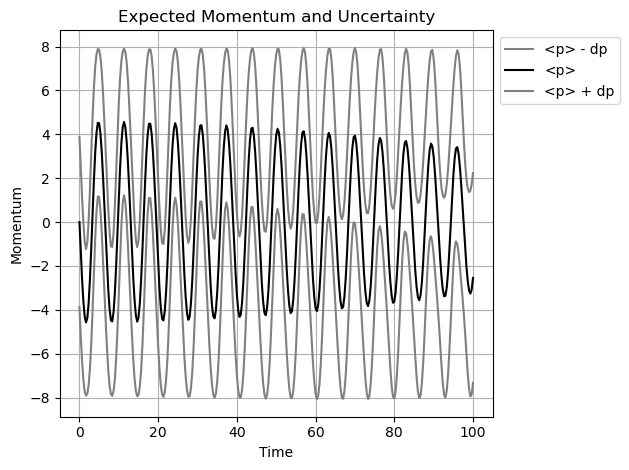

In [10]:
# Numeric momentum functions
p.expected_momentum_and_uncertainty_are_calculated((0.0, tempo), coeficientes, pontos)
p.expected_momentum_and_uncertainty_are_plotted()

In [11]:
# NUMERIC FUNCTIONS: <p> e dp
expected_momentum_func = p.expected_momentum(coeficientes)
momentum_uncertainty_func = p.momentum_uncertainty(coeficientes)
for i in range(0, int(tempo) + 1, 5):
    print(f"t={i}: <p> = {expected_momentum_func(i):.15} | dp = {momentum_uncertainty_func(i):.15}")

t=0: <p> = 0.0 | dp = 3.87324531036894
t=5: <p> = 4.50633380368976 | dp = 3.35380099893388
t=10: <p> = 1.08812777190475 | dp = 4.35130455801547
t=15: <p> = -4.36225642846156 | dp = 3.5146776825815
t=20: <p> = -1.87904923671876 | dp = 3.78212015630542
t=25: <p> = 3.6506029076102 | dp = 3.67973619079123
t=30: <p> = 2.94763708933559 | dp = 3.9310786816883
t=35: <p> = -3.21619720091767 | dp = 4.06949587919626
t=40: <p> = -3.30249591818231 | dp = 3.68727183367653
t=45: <p> = 2.08649030169303 | dp = 3.97216419908985
t=50: <p> = 3.97173879778333 | dp = 3.66547279788431
t=55: <p> = -1.38485741665849 | dp = 4.43010262944246
t=60: <p> = -3.9302154801538 | dp = 3.90941476689694
t=65: <p> = 0.276690751991095 | dp = 3.9536788493262
t=70: <p> = 3.9385742477024 | dp = 3.99535198858986
t=75: <p> = 0.584207831770727 | dp = 4.33624152944926
t=80: <p> = -3.63346966129951 | dp = 4.40957626341951
t=85: <p> = -1.29624907361934 | dp = 3.85980325460656
t=90: <p> = 2.98460494216043 | dp = 4.47927219328617
t=95

Minimum value of dp(t) / <p>(t): -55.791507340749590
Estimated period (s):
t = 35.785953177257525
Full results saved in: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_min_relative_momentum_uncertainty.txt


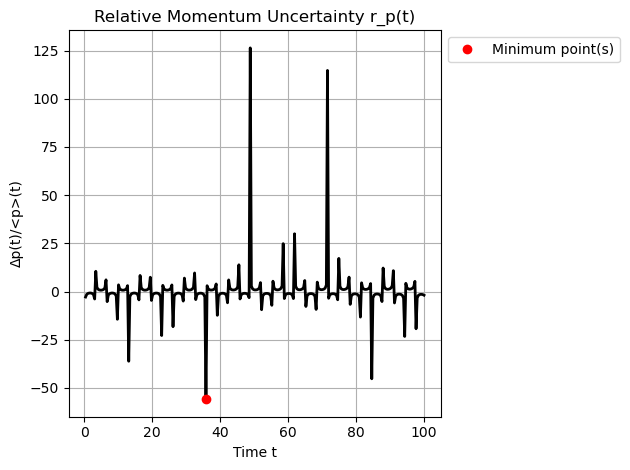

(<Figure size 640x480 with 1 Axes>,
 np.float64(-55.79150734074959),
 [np.float64(35.785953177257525)])

In [12]:
# Relative uncertainties
p.momentum_uncertainty_relative(coeficientes, t_max=tempo, num_points=pontos)

Eigenpairs saved in: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_Eigenpairs.txt
--- Processing 3 levels ---
-> Saved TXT: Level 0
-> Saved TXT: Level 1
-> Saved TXT: Level 2
-> Image saved: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_eigenfunctions.png


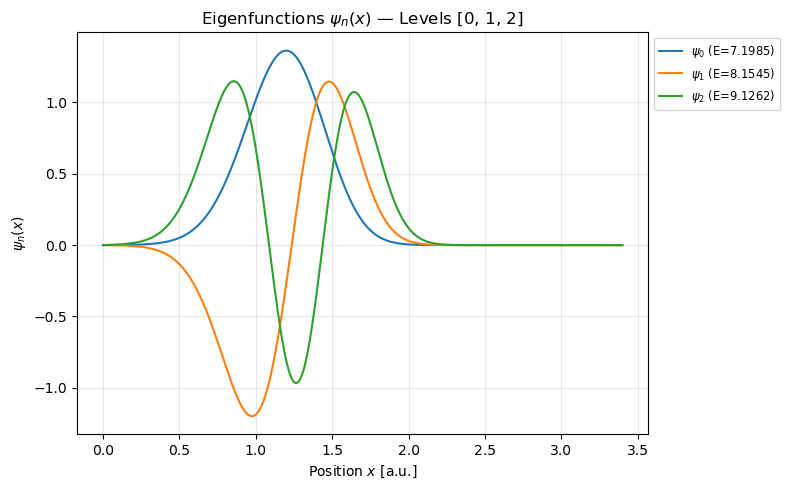

In [13]:
p.plot_eigenfunctions(num_levels=3, save=True)

Plot image saved: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_plot_t0.00_20260217_165212.png


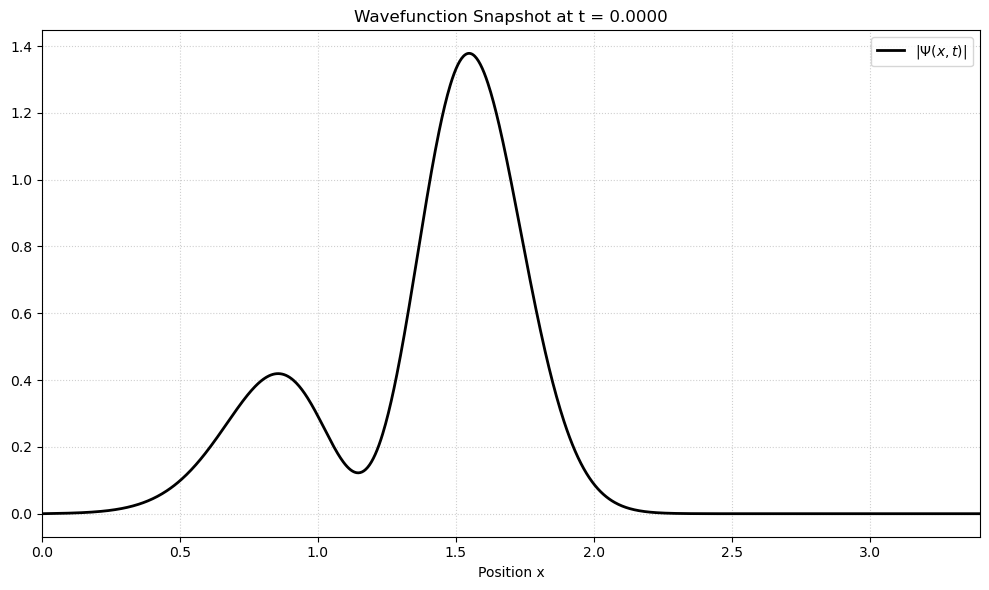

Exporting wavefunction data to: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_data_t0.00_20260217_165214.txt ...
-> Data export successful.


In [14]:
# Wavefunction: plot and export data
instante_t = 0
p.plot_wavefunction_snapshot(t=instante_t, coefficients=coeficientes, save_data=True)

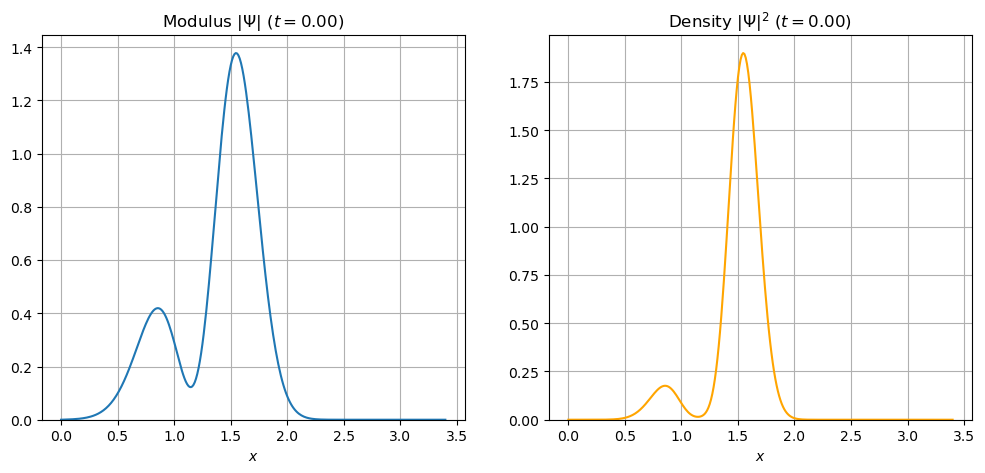

In [15]:
p.plot_wavefunction_and_density(
            t=0,
            coefficients=coeficientes,
            num_slices=300,
            color_psi="blue",
            linestyle_psi="-",
            color_rho="red",
            alpha_rho=0.5,
            title="|psi| e |psi|² em t=0",
            xlabel="x",
        )

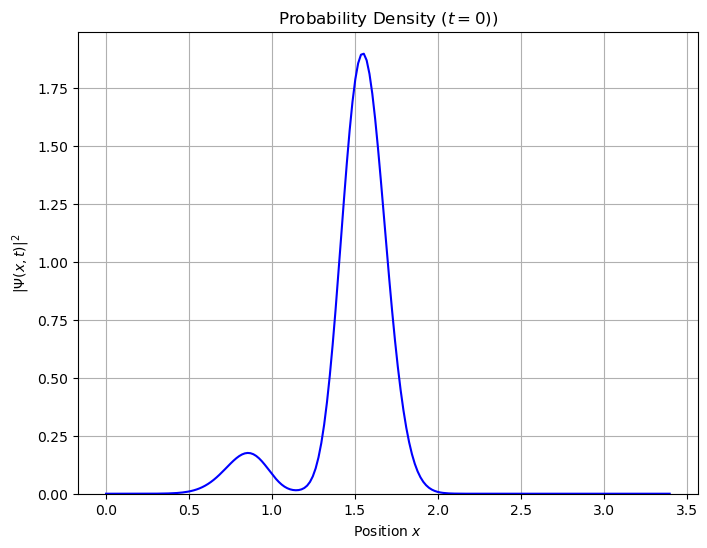

In [16]:
# Tempo t = 0
t_value = 0

# Chama a função para gerar o gráfico
#p.probability_density_is_plotted(t_value, coefficients, num_slices=200, color='blue', title="Probabilidade |ψ(x,t=0)|²", xlabel="Posição x", ylabel="|ψ(x,t)|²")
p.probability_density_is_plotted(t_value, coeficientes)

Computing density frames…


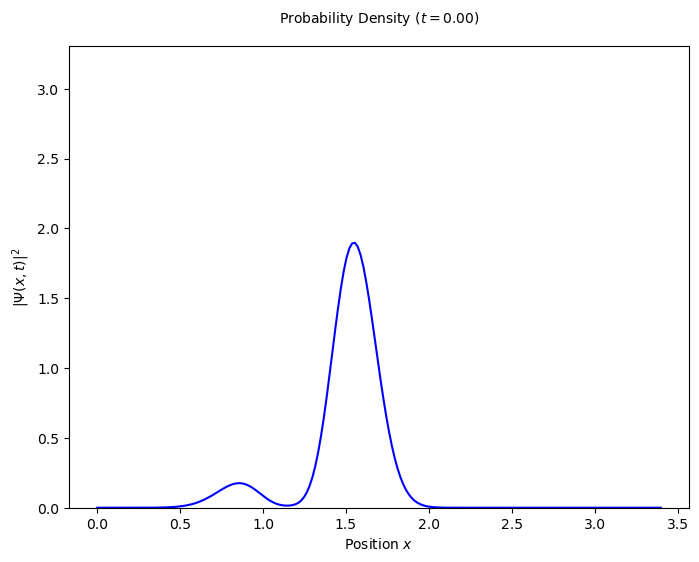

In [17]:
# Intervalo de tempo de 0 a 20
time_interval = (0, 20)

# Chamada para gerar a animação com o padrão (10 frames)
#p.probability_density_is_plotted(time_interval, coefficients, num_frames=10, num_slices=200, color='blue', title="Probabilidade |ψ(x,t)|²",		 xlabel="Posição x", ylabel="|ψ(x,t)|²")

p.probability_density_is_plotted(time_interval, coeficientes)

Computing density frames…


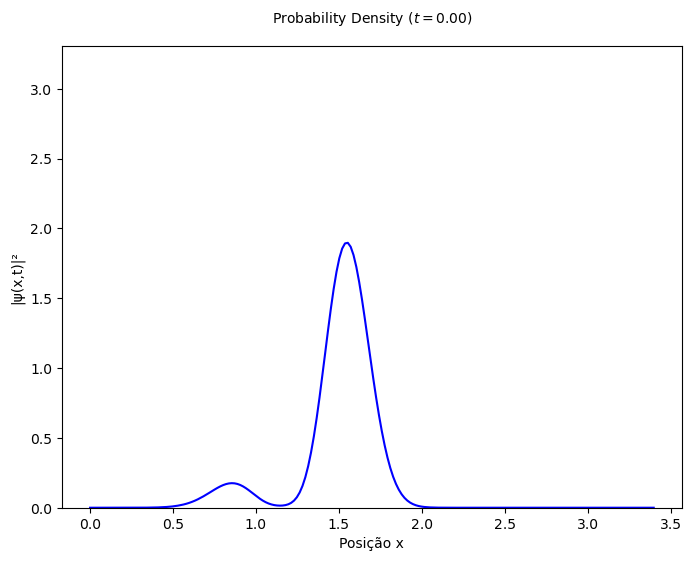

In [18]:
# Para gerar uma animação com 20 frames:
p.probability_density_is_plotted(time_interval, 
                                 coeficientes, 
                                 num_frames=100, 
                                 num_slices=200,
                                 save_as_gif=True, 
                                 gif_filename="stiff_prob_density.gif",
                                 color='blue', 
                                 title="Probabilidade |ψ(x,t)|²",
                                 xlabel="Posição x", ylabel="|ψ(x,t)|²")

In [ ]:
# Supondo que você queira ver a evolução de t=0 até t=20
p.plot_wavefunction_3d(
    t_span=(0, 1),       # Intervalo de tempo
    coefficients=coeficientes,
    num_x=10000,            # Pontos no eixo X (resolução espacial)
    num_t=10000,            # Pontos no eixo T (resolução temporal/frames)
    save_data=True,
    #elev=40, azim=-30 # Ângulo de visão (opcional, para pegar o melhor ângulo)
)

Computing time evolution from t=0 to t=1...


Computing density surface (10000x10000)...
Saving 3D Density plot to: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_ProbabilityDensity3D_Static.png ...


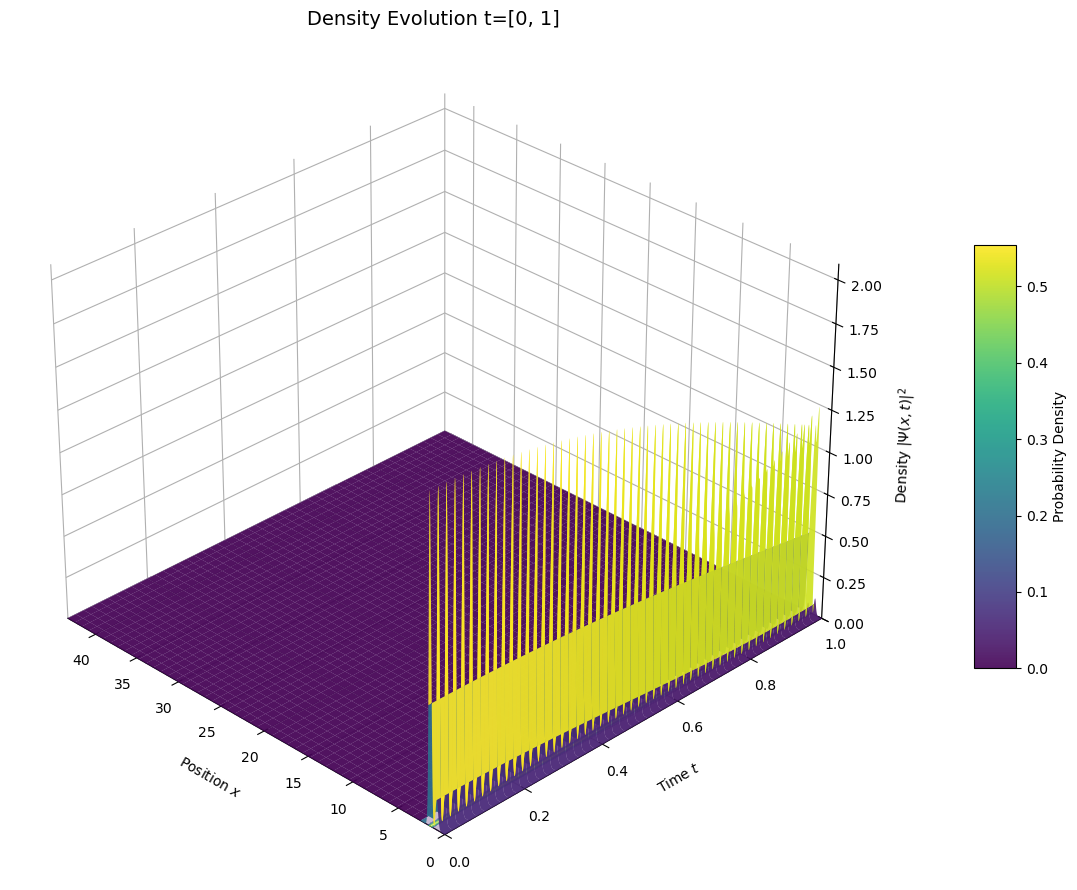

Exporting Density data to: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_ProbabilityDensity3D_Static_Data_20260127_134307.txt ...
Data export successful.


(<Figure size 1200x900 with 2 Axes>,
 <Axes3D: title={'center': 'Density Evolution t=[0, 1]'}, xlabel='Position $x$', ylabel='Time $t$', zlabel='Density $|\\Psi(x,t)|^2$'>)

In [ ]:
p.plot_probability_density_3d_static(
    t_interval=(0, 1),
    coefficients=coeficientes,
    num_t=10000, 
    num_x=10000,
    # Visualização
    invert_x_axis=True,  # Inverte o X
    #elev=40, azim=130,   # Ajuste fino do ângulo
    #cmap='viridis',      # Ou 'plasma', 'inferno', 'gray'
    # Arquivos
    # plot_filename="densidade_estatica.png",
    save_data=True
)

In [ ]:
# # Intervalo de tempo para o gráfico 3D: por exemplo, de t=0 até t=20
t_interval = (0, 20)

# # Chama o método para gerar o gráfico 3D estático
p.probability_density_3d(t_interval, 
                         coeficientes, 
                         num_frames=50, 
                         num_slices=200,
                         title="Gráfico 3D da Densidade de Probabilidade",
                         xlabel="Posição x", 
                         ylabel="Tempo t", 
                         zlabel="|ψ(x,t)|²")

Calculando superfície 3D...
-> 3D GIF saved: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_probability_density_3d.gif


(<Figure size 1000x800 with 2 Axes>,
 <Axes3D: title={'center': 'Gráfico 3D da Densidade de Probabilidade'}, xlabel='Posição x', ylabel='Tempo t', zlabel='|ψ(x,t)|²'>,
 array([[0.00000000e+00, 5.37958867e-05, 3.61548976e-03, ...,
         1.82223425e-24, 5.15794310e-23, 1.65096202e-29],
        [0.00000000e+00, 5.26973926e-05, 3.48597049e-03, ...,
         1.79014553e-24, 5.16859188e-23, 1.59237984e-29],
        [0.00000000e+00, 5.41516355e-05, 3.48964960e-03, ...,
         1.81114702e-24, 5.51835403e-23, 1.43137062e-29],
        ...,
        [0.00000000e+00, 4.93319923e-05, 3.25351629e-03, ...,
         1.70404750e-24, 4.85678397e-23, 1.59352512e-29],
        [0.00000000e+00, 5.56929587e-05, 3.75941912e-03, ...,
         1.86826671e-24, 5.31137426e-23, 1.64370208e-29],
        [0.00000000e+00, 5.95985028e-05, 3.98687461e-03, ...,
         1.96204461e-24, 5.76595522e-23, 1.57787527e-29]]),
 array([ 0.        ,  0.40816327,  0.81632653,  1.2244898 ,  1.63265306,
         2.04081633,  2.

In [ ]:
# Norm of wave function
n = p.norm_of_wave_function(coeficientes)
for t in np.linspace(0, tempo, 100):
    print(f"Norm at t={t:.1f}: {n(t):.15}")

Norm at t=0.0: 1.00000000000003
Norm at t=1.0: 1.0
Norm at t=2.0: 0.99999999999995
Norm at t=3.0: 0.999999999999918
Norm at t=4.0: 0.999999999999931
Norm at t=5.1: 0.99999999999998
Norm at t=6.1: 1.00000000000003
Norm at t=7.1: 1.00000000000002
Norm at t=8.1: 0.999999999999974
Norm at t=9.1: 0.999999999999927
Norm at t=10.1: 0.99999999999992
Norm at t=11.1: 0.999999999999956
Norm at t=12.1: 1.00000000000001
Norm at t=13.1: 1.00000000000003
Norm at t=14.1: 0.999999999999998
Norm at t=15.2: 0.999999999999944
Norm at t=16.2: 0.999999999999918
Norm at t=17.2: 0.999999999999936
Norm at t=18.2: 0.999999999999987
Norm at t=19.2: 1.00000000000003
Norm at t=20.2: 1.00000000000002
Norm at t=21.2: 0.999999999999967
Norm at t=22.2: 0.999999999999924
Norm at t=23.2: 0.999999999999923
Norm at t=24.2: 0.999999999999962
Norm at t=25.3: 1.00000000000001
Norm at t=26.3: 1.00000000000003
Norm at t=27.3: 0.999999999999992
Norm at t=28.3: 0.999999999999939
Norm at t=29.3: 0.999999999999918
Norm at t=30.3: 

In [ ]:
# Heisenberg uncertainty
heis_fn = p.heisenberg_uncertainty(coeficientes)
for i in range(0, int(tempo) + 1, 5):
    result = heis_fn(t=i)
    print(f"t={i} | dx.dp = {result['dx.dp']:.15} | Heisenberg satisfy? {result['valid']}")

t=0 | dx.dp = 0.721850164939289 | Heisenberg satisfy? True
t=5 | dx.dp = 0.740832818795174 | Heisenberg satisfy? True
t=10 | dx.dp = 0.901468169726158 | Heisenberg satisfy? True
t=15 | dx.dp = 0.811912770588109 | Heisenberg satisfy? True
t=20 | dx.dp = 0.730736733649995 | Heisenberg satisfy? True
t=25 | dx.dp = 0.744386095905663 | Heisenberg satisfy? True
t=30 | dx.dp = 0.925204511289387 | Heisenberg satisfy? True
t=35 | dx.dp = 0.916250061138115 | Heisenberg satisfy? True
t=40 | dx.dp = 0.762688540988059 | Heisenberg satisfy? True
t=45 | dx.dp = 0.794919695640727 | Heisenberg satisfy? True
t=50 | dx.dp = 0.918480757546696 | Heisenberg satisfy? True
t=55 | dx.dp = 0.991940056357759 | Heisenberg satisfy? True
t=60 | dx.dp = 0.847495794544375 | Heisenberg satisfy? True
t=65 | dx.dp = 0.884445382887872 | Heisenberg satisfy? True
t=70 | dx.dp = 0.953633995003035 | Heisenberg satisfy? True
t=75 | dx.dp = 1.07656885333358 | Heisenberg satisfy? True
t=80 | dx.dp = 0.976556054849787 | Heisenbe

Analysis results saved at: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_PositionAnalysis.txt
Análise de <x>(t):
- Number of detected MAXIMA: 15
- Number of detected MINIMA: 15
- Average Period: 6.5000 ± 0.1667
- Average amplitude: 0.2777
- Mean value: 1.2739


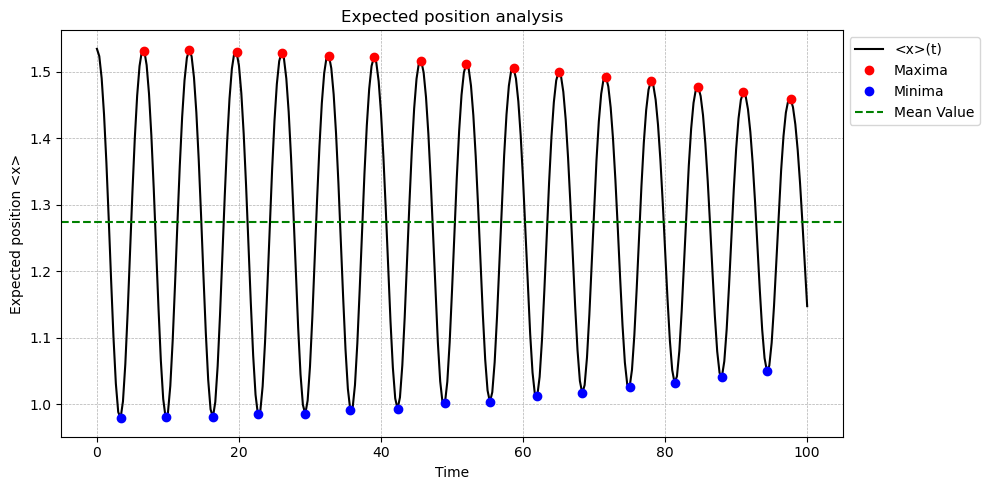

In [ ]:
# "ANALYZE EXPECTED POSITION"
p.analyze_expected_position()

Building matrices for verification...
Reporting errors in equations in file: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_Check_Equations.txt
Reporting errors in eigenvector normality in file: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_Check_Normality.txt
Reporting errors in eigenvector orthogonality in file: k1_l-1_b0.27_s0.9999/k1_l-1_b0.27_s0.9999_Check_Orthogonality.txt
Numerical verification Done.


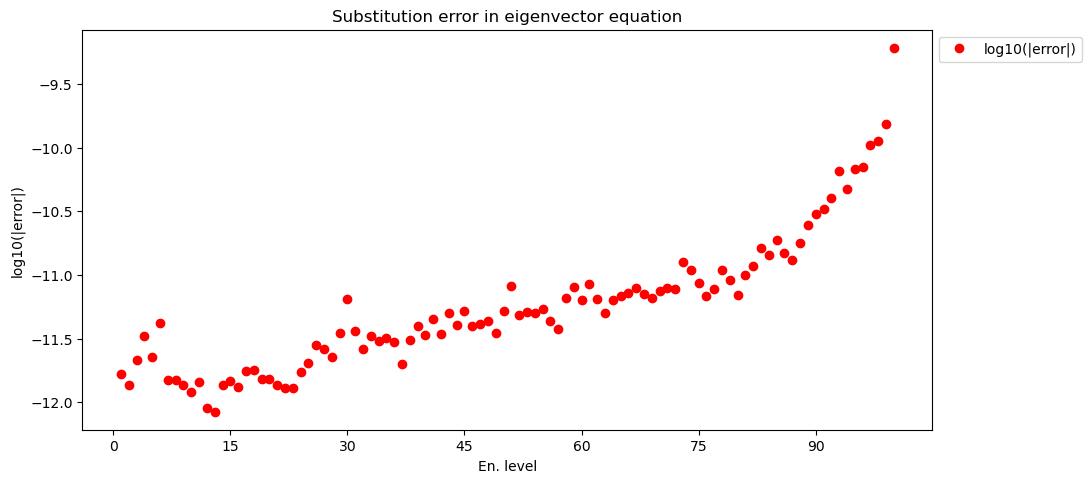

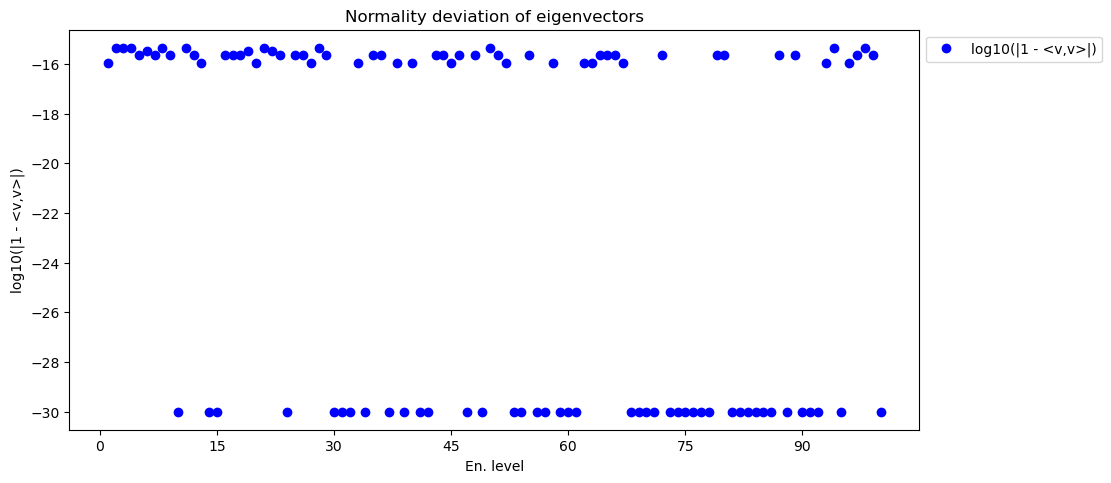

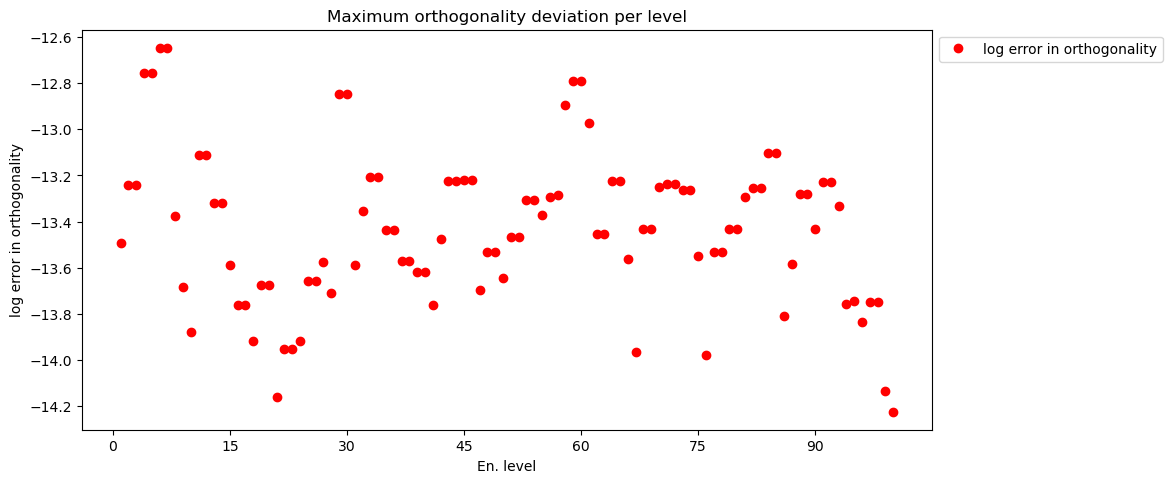

--------------------------------------------------------------------------------
---------------- Orthogonality Summary (2D curve) ----------------


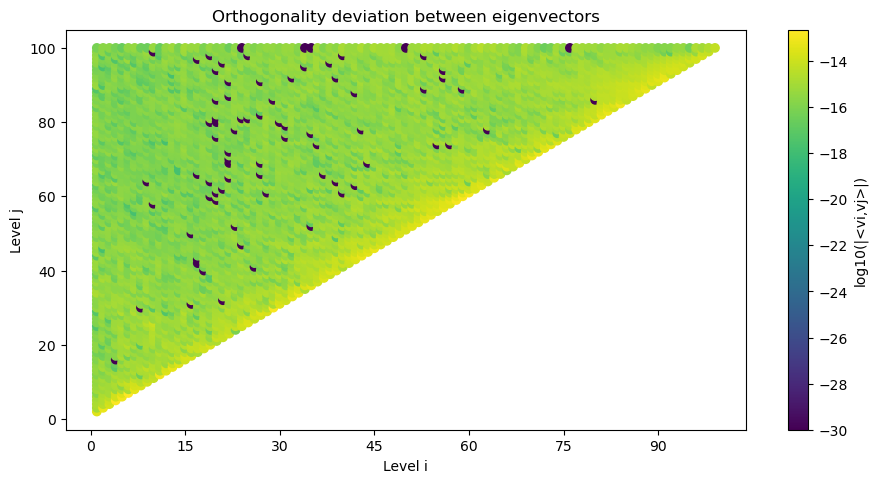

Graphical check Done.


In [ ]:
# Check solutions
p.check_solutions_numerically()
p.check_solutions_graphically()